In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

In [2]:
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

In [3]:
df = pd.merge(orders, items, on='order_id')

In [4]:
df = pd.merge(df, products, on='product_id')

In [5]:
# quantas linhas e colunas tem ?
df.shape


(112650, 22)

In [6]:

# quais são as colunas categoricas e qualitativas do Dataset
df.info()
# o Dataset tem nulos
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   customer_id                    112650 non-null  object 
 2   order_status                   112650 non-null  object 
 3   order_purchase_timestamp       112650 non-null  object 
 4   order_approved_at              112635 non-null  object 
 5   order_delivered_carrier_date   111456 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  112650 non-null  object 
 8   order_item_id                  112650 non-null  int64  
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price                         

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
dtype: int64

In [17]:

padronizacao = {
    # Unificando Construção e Ferramentas
    'construcao_ferramentas_jardim': 'construcao_e_ferramentas',
    'construcao_ferramentas_construcao': 'construcao_e_ferramentas',
    'construcao_ferramentas_iluminacao': 'construcao_e_ferramentas',
    'construcao_ferramentas_seguranca': 'construcao_e_ferramentas',
    'construcao_ferramentas_casa': 'construcao_e_ferramentas',
    'construcao_ferramentas_ferramentas': 'construcao_e_ferramentas',
    
    # Unificando Móveis e Decoração
    'moveis_decoracao': 'moveis_e_decoracao',
    'moveis_escritorio': 'moveis_e_decoracao',
    'moveis_quarto': 'moveis_e_decoracao',
    'moveis_sala': 'moveis_e_decoracao',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'moveis_e_decoracao',
    'moveis_colchao_e_estofado': 'moveis_e_decoracao',
    
    # Unificando Eletros
    'eletrodomesticos_2': 'eletrodomesticos',
    'portateis_cozinha_e_preparadores_de_alimentos': 'eletroportateis',
    'portateis_casa_forno_e_cafe': 'eletroportateis',
    'la_cuisine': 'eletroportateis',
    
    # Unificando Informática e Tecnologia
    'pcs': 'informatica_acessorios',
    'pc_gamer': 'informatica_acessorios',
    'tablets_impressao_imagem': 'informatica_acessorios',
    
    # Unificando Moda (Fashion)
    'fashion_underwear_e_moda_praia': 'fashion_e_acessorios',
    'fashion_bolsas_e_acessorios': 'fashion_e_acessorios',
    'fashion_calcados': 'fashion_e_acessorios',
    'fashion_roupa_masculina': 'fashion_e_acessorios',
    'fashion_roupa_feminina': 'fashion_e_acessorios',
    'fashion_esporte': 'fashion_e_acessorios',
    'fashion_roupa_infanto_juvenil': 'fashion_e_acessorios',
    
   
    'casa_conforto_2': 'casa_conforto',
    'alimentos_bebidas': 'alimentos'
}

# 2. Aplicando a substituição
df['product_category_name'] = df['product_category_name'].replace(padronizacao)



In [7]:
# converter colunas que deveriam ser datetime para datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'])


In [ ]:
#tiramos os nulos NaT que estavam em approved_at substituindo pela data da compra, tendo em vista que todos eles tinham sido dados como entregue ao cliente 
df['order_approved_at'] = df['order_approved_at'].fillna(df['order_purchase_timestamp'])
df.head(20)

NameError: name 'df' is not defined

In [18]:
condicao = (df['order_delivered_customer_date'].isna())&(df['order_status']=='delivered')

df.loc[condicao,'order_delivered_customer_date'] = df.loc[condicao,'order_estimated_delivery_date']


df.loc[
    (df['order_status'] == 'canceled') & 
    (df['order_delivered_customer_date'].notna()),
    'order_status'
] = 'delivered'
#substitui produtos com status cancelado e com entrega feita ao cliente por status delivered, para manter o padrao de negocio 

#substitiu todos os valores que atender a condicao pela data de entrega estimada, pois, notificou que ja havia sido entregue e a data de entregue ao cliente tava nula

In [19]:

#Os valores nulos na data de entrega ao cliente estão associados a pedidos que não foram concluídos,
#como pedidos em processamento, enviados, cancelados ou indisponíveis.
#Esses dados foram mantidos, pois representam corretamente o fluxo do negócio.

In [20]:
# montei uma coluna tempo_entrega 
df['tempo_entrega'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

In [21]:
#montei uma coluna tempo_atraso
df['tempo_atraso'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

In [22]:
#removendo outliers de price para melhorar a leitura do dataset com dados mais frequentes e não raros

q1 = df['price'].quantile(0.01)
q99 = df['price'].quantile(0.99)
df = df[(df['price']>q1) & (df['price']<q99)]


In [23]:
#removendo outliers de frete 
q1 = df['freight_value'].quantile(0.01)
q99 = df['freight_value'].quantile(0.99)
df = df[(df['freight_value']>q1) & (df['freight_value']<q99)]


In [24]:
df['product_name_lenght'] = df['product_name_lenght'].fillna('sem_nome')
df['product_description_lenght'] = df['product_description_lenght'].fillna('sem_discrição')
df['product_photos_qty'] = df['product_photos_qty'].fillna('sem_fotos')
df['product_category_name'] = df['product_category_name'].fillna('sem_nome')

In [25]:
df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1101
order_delivered_customer_date    2314
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                   17
product_length_cm                  17
product_height_cm                  17
product_width_cm                   17
tempo_entrega                    2314
tempo_atraso                        0
dtype: int64

In [26]:
#uma lista com as colunas que queremos verificar
colunas_medidas = [
    'product_weight_g', 
    'product_length_cm', 
    'product_height_cm', 
    'product_width_cm'
]

# O "df =" garante que estamos salvando a alteração
df = df.dropna(subset=colunas_medidas)

In [27]:
df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1101
order_delivered_customer_date    2314
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
tempo_entrega                    2314
tempo_atraso                        0
dtype: int64

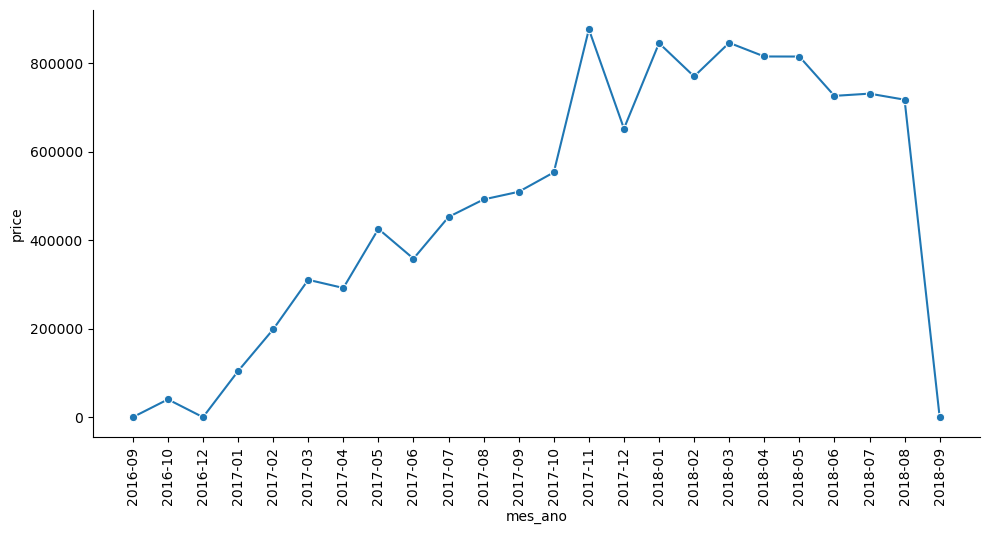

In [28]:
df['mes_ano'] = df['order_purchase_timestamp'].dt.to_period('M')

faturamento = df.groupby('mes_ano')['price'].sum().reset_index()

faturamento['mes_ano'] = faturamento['mes_ano'].astype(str)

sns.relplot(data = faturamento,x='mes_ano',y='price',kind='line',marker='o',aspect=2,)
plt.xticks(rotation = 90)
plt.show()

#este gráfico ilustra a evolução do faturamento mensal da operação. Fica claro um período de crescimento contínuo ao longo de 2017, que culmina em um pico expressivo em novembro, destacando o forte impacto da Black Friday nas vendas.
#O dado mais positivo é que, após essa data, o faturamento de 2018 não retrocedeu; ele se estabilizou em um patamar consideravelmente mais alto, indicando uma consolidação do negócio.
#É importante ressaltar também que os valores quase zerados no fim de 2016 e a queda abrupta em setembro de 2018 são apenas ruídos nos dados — representam, respectivamente, o período de início da coleta de registros e o momento em que a base foi extraída (mês incompleto), e não uma queda real nas vendas.

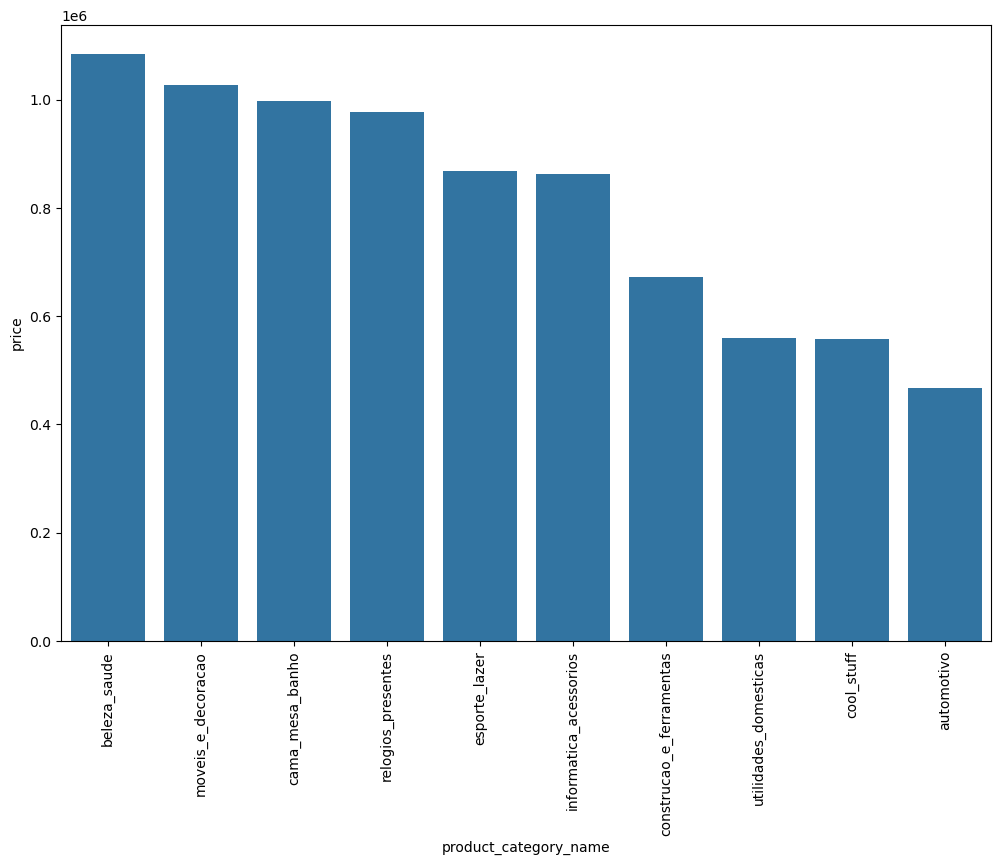

In [29]:
top_categoria = df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12,8))
sns.barplot(data = top_categoria,x='product_category_name',y='price')
plt.xticks(rotation = 90)
plt.show()

#neste segundo gráfico, focamos no faturamento acumulado por categoria para entender o que mais traz dinheiro para a empresa. O grande destaque é o setor de 'Beleza e Saúde', que lidera o ranking isolado com mais de 1 milhão em receita.
#Logo em seguida, vemos um empate técnico muito forte entre 'Cama, Mesa e Banho' e 'Relógios e Presentes'. Isso nos revela o perfil de compra do nosso cliente, que tem uma forte preferência por itens de cuidado pessoal,
#conforto para o lar e presentes. Estrategicamente, esses dados nos mostram que essas são as categorias essenciais do negócio, nas quais não podemos admitir rupturas de estoque.

In [30]:
dfentregues=df[df['order_status']=='delivered']

dfentregues['tempo_entrega'].mean()

np.float64(11.968409709618875)

In [31]:
dfentregues['tempo_atraso'].value_counts(normalize=True)*100


tempo_atraso
False    92.095811
True      7.904189
Name: proportion, dtype: float64

<Axes: ylabel='freight_value'>

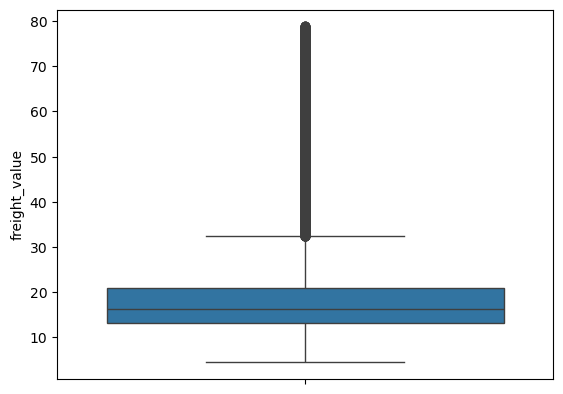

In [32]:
sns.boxplot(df['freight_value'])

#nesta parte nós entramos na análise logística da operação, unindo três indicadores cruciais. Primeiro, calculamos que o tempo médio de entrega para o cliente final é de aproximadamente 12 dias.
#Em seguida, validamos que a taxa de pontualidade é muito boa: 92% dos pedidos chegam dentro do prazo, com apenas cerca de 8% de atraso. Por fim, analisamos o custo desse transporte através do boxplot do valor do frete (freight_value).
#A caixa nos mostra que o frete padrão é relativamente baixo, concentrado na faixa de 13 a 20 reais, com a mediana ali perto dos 16 reais. Contudo, essa linha preta grossa acima do gráfico representa uma grande quantidade de outliers (valores atípicos) chegando a 80 reais.
#Isso indica que, embora o frete geral seja barato, temos um volume considerável de pedidos que pagam fretes bem mais caros, provavelmente devido a entregas em regiões muito distantes (Norte/Nordeste) ou de produtos muito pesados.

<Axes: xlabel='price', ylabel='freight_value'>

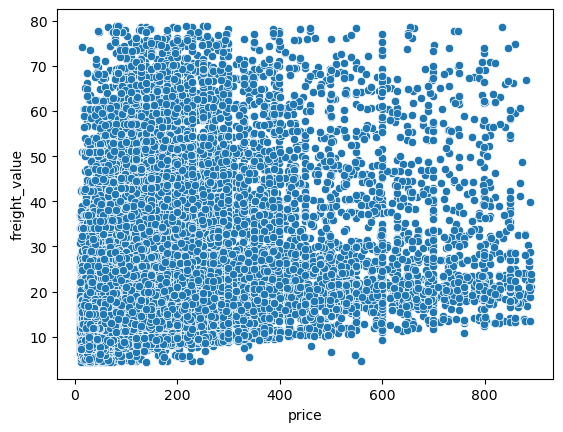

In [33]:
sns.scatterplot(data = df, x = 'price', y = 'freight_value')

#neste gráfico de dispersão, cruzamos o preço do produto no eixo X com o valor do frete no eixo Y para verificar se existe alguma relação direta entre eles.
#O resultado é essa grande 'nuvem' de pontos dispersos, o que nos mostra visualmente que não há uma correlação clara entre o valor comercial do item e o custo logístico. Podemos observar produtos baratos, na casa dos 50 reais,
#pagando um frete alto de 80 reais, assim como temos produtos caros, de 800 reais, com fretes bem baratos, próximos a 15 reais. A conclusão de negócio que tiramos disso é que o valor do frete da nossa operação é definido quase exclusivamente por fatores físicos e geográficos,
#como o peso, o volume da caixa e a distância até a casa do cliente, independentemente do produto ser um item de luxo ou de baixo custo.

,order_status,count
0,delivered,105792
1,shipped,1147
2,canceled,496
3,invoiced,332
4,processing,330
5,unavailable,6
6,approved,3


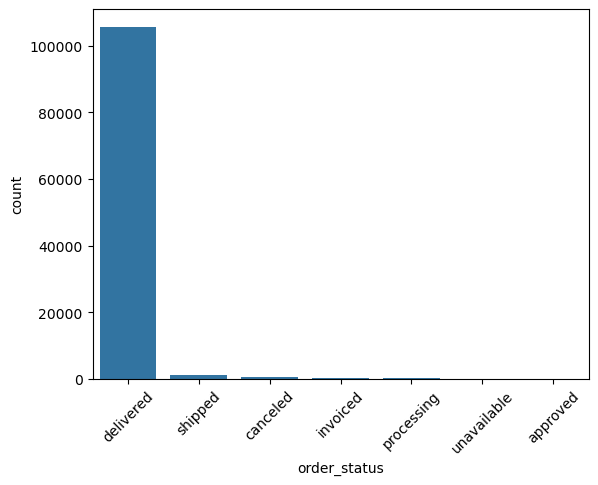

In [34]:
ordens=df['order_status'].value_counts().reset_index()

sns.barplot(data = ordens,x='order_status',y='count')
plt.xticks(rotation = 45)

ordens

#neste gráfico analisamos a distribuição do status dos pedidos na nossa base. Como fica muito claro visualmente, existe uma concentração esmagadora no status 'delivered' (entregue),
#que ultrapassa a marca de 105 mil registros. As demais categorias, como pedidos apenas enviados ('shipped'), cancelados ou em processamento, são quase imperceptíveis no gráfico, representando uma fração minúscula do total.
#A principal conclusão que tiramos disso é dupla: primeiro, que nossa base de dados reflete um histórico consolidado de vendas já finalizadas (o que é excelente para análises de pós-venda); segundo, comprova que a operação tem uma taxa de sucesso altíssima,
#com um índice de cancelamento ou falha logística que é praticamente insignificante frente ao volume total operado.

<function matplotlib.pyplot.show(close=None, block=None)>

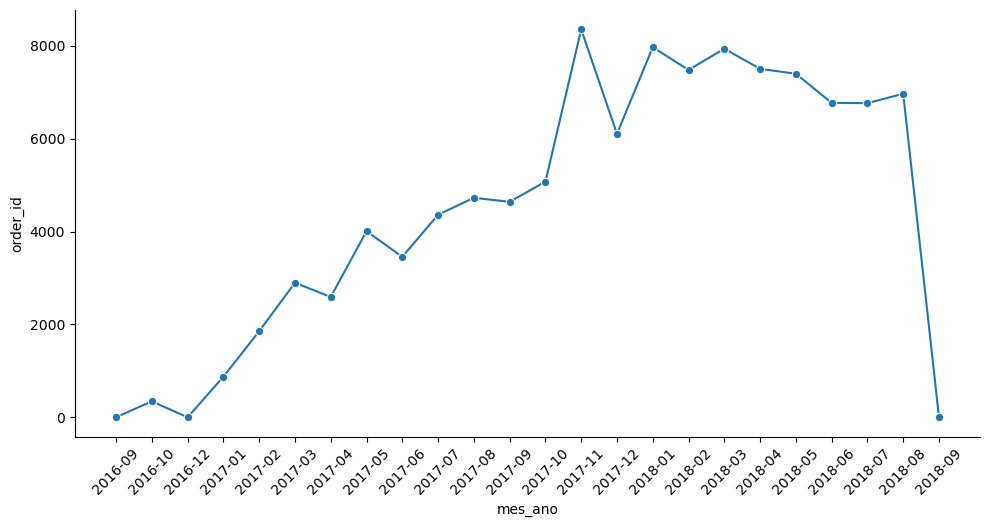

In [35]:
pedidos_mes = df.groupby('mes_ano')['order_id'].count().reset_index()
pedidos_mes['mes_ano'] = pedidos_mes['mes_ano'].astype(str)
sns.relplot(data = pedidos_mes,x = 'mes_ano',y='order_id',kind='line',marker='o',aspect=2)
plt.xticks(rotation = 45)
plt.show

#neste gráfico nós analisamos o volume total de pedidos realizados mês a mês. É muito interessante notar que o comportamento dessa curva é praticamente idêntico ao nosso primeiro gráfico,
#que mostrava o faturamento. Vemos a mesma rampa de crescimento em 2017, o grande pico ultrapassando 8 mil pedidos na Black Friday de novembro, e a manutenção de um patamar elevado ao longo de 2018.
#O principal insight de negócio que tiramos ao comparar esses dois gráficos é que o aumento expressivo da nossa receita foi tracionado pelo ganho de escala. Ou seja,
#a empresa de fato expandiu sua base de clientes e passou a processar um volume físico muito maior de vendas, comprovando um crescimento real da operação e do market share, e não apenas um aumento no preço dos produtos vendidos.

<Axes: xlabel='tempo_entrega', ylabel='Count'>

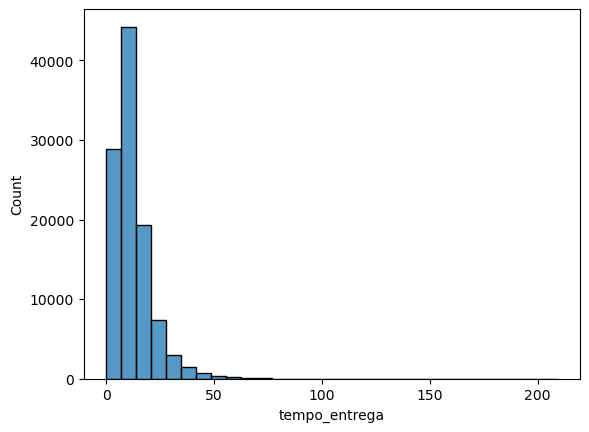

In [36]:
sns.histplot(data = dfentregues['tempo_entrega'],bins=30)

#neste histograma detalhamos a distribuição do tempo de entrega dos nossos pedidos. O gráfico apresenta uma clássica distribuição com assimetria à direita.
#O grande volume concentrado nas primeiras barras confirma nossa análise anterior: a esmagadora maioria das entregas ocorre de forma muito rápida, concentrada entre 0 e 20 dias. No entanto,
#o ponto de atenção mais importante revelado por esta visualização é a 'cauda longa' que se estende para a direita. Ela evidencia a existência de casos extremos onde o cliente esperou 50, 100 e até 200 dias para receber o produto.
#Para a operação, a conclusão é que, embora o fluxo logístico padrão seja muito eficiente, existem gargalos severos ou extravios em uma minoria dos pedidos que precisam ser investigados, pois são esses casos que geram o maior dano à reputação da marca.

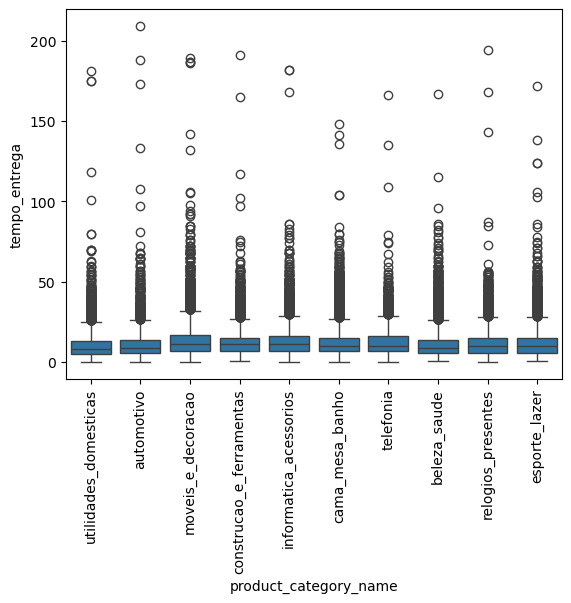

In [37]:
top10 = df['product_category_name'].value_counts().head(10).index
sns.boxplot(data = dfentregues[dfentregues['product_category_name'].isin(top10)],x='product_category_name',y='tempo_entrega')
plt.xticks(rotation = 90)
plt.show()

#neste gráfico nós cruzamos o tempo de entrega com as 10 categorias de produtos mais vendidas para entender se o tipo de produto afeta o prazo logístico. O que salta aos olhos imediatamente é a uniformidade das 'caixas' azuis.
#Isso nos mostra que, no fluxo normal, o tempo de entrega é praticamente o mesmo para qualquer categoria, com a mediana sempre ali perto dos 10 a 12 dias. Ou seja, a transportadora entrega um relógio ou um item de cama, mesa e banho com a mesma agilidade padrão.
#O grande gargalo, como podemos ver pelos inúmeros pontos acima das caixas, são os outliers (casos atípicos). Todas as categorias sofrem com atrasos severos,
#mas vale destacar que setores com produtos potencialmente mais volumosos e pesados, como 'Móveis e Decoração' e 'Automotivo', registram os piores extremos absolutos,
#chegando a mais de 200 dias de espera, o que aponta para uma dificuldade pontual na logística de itens grandes.

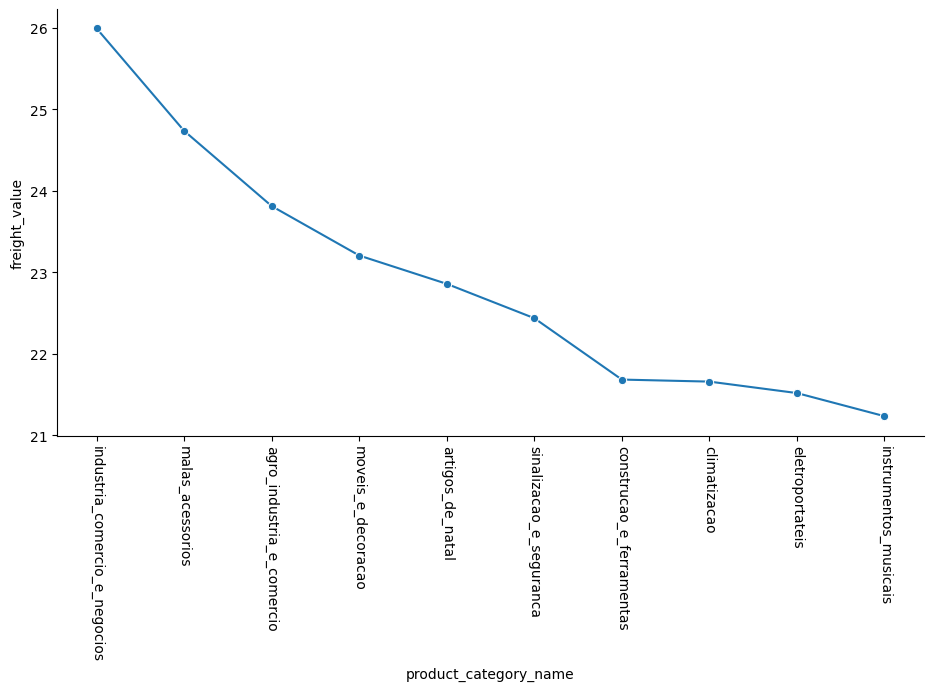

In [38]:
frete_cat = df.groupby('product_category_name')['freight_value'].mean().sort_values(ascending=False).head(10).reset_index()
sns.relplot(data = frete_cat,x = 'product_category_name',y='freight_value',kind='line',marker = 'o',aspect=2)
plt.xticks(rotation = 270)
plt.show()

#para fechar o raciocínio sobre os custos logísticos que começamos naquele gráfico de dispersão, este gráfico de linha destaca as 10 categorias com o maior valor médio de frete.
#A categoria 'PCs' lidera o ranking, seguida em peso por um grande bloco de móveis (colchões, estofados, móveis de quarto e escritório) e eletrodomésticos. Esse resultado valida perfeitamente a nossa hipótese anterior:
#o que realmente encarece o frete na nossa operação não é o valor comercial do produto, mas sim o seu volume físico e peso. Itens grandes, pesados ou que exigem manuseio especial,
#como mobília e computadores, naturalmente possuem uma logística mais complexa e cara, elevando a média do frete dessas categorias para a faixa dos 35 a 42 reais.

<Axes: xlabel='price', ylabel='Count'>

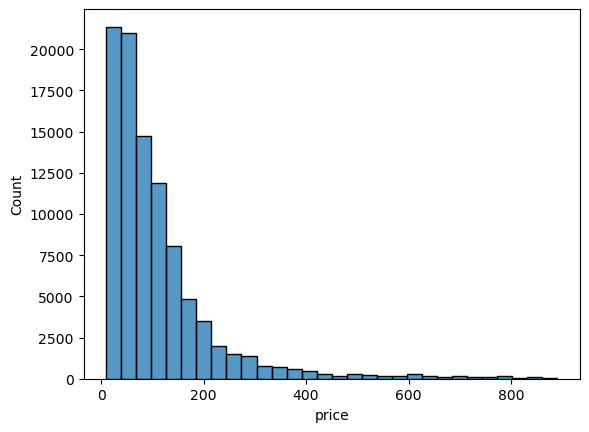

In [39]:
ticket = df.groupby('order_id')['price'].mean()
sns.histplot(data = ticket,bins=30)

#neste histograma nós analisamos a distribuição do valor médio dos pedidos, também conhecido como ticket médio. O gráfico apresenta uma forte assimetria à direita,
#mostrando que a esmagadora maioria das nossas vendas está concentrada em valores mais baixos, na faixa de até 150 a 200 reais.
#A conclusão estratégica que tiramos dessa visualização é que o nosso e-commerce é uma operação de 'alto giro', muito baseada em produtos acessíveis para o consumidor.
#Embora exista uma longa cauda no gráfico indicando a venda de itens mais caros, chegando a 800 reais, eles representam uma exceção no volume total. Portanto,
#isso nos mostra que qualquer política de desconto ou estratégia de frete grátis da empresa deve ser calculada com muito cuidado,
#pois a margem de lucro em produtos de menor valor costuma ser mais apertada.

<Axes: xlabel='order_item_id', ylabel='Count'>

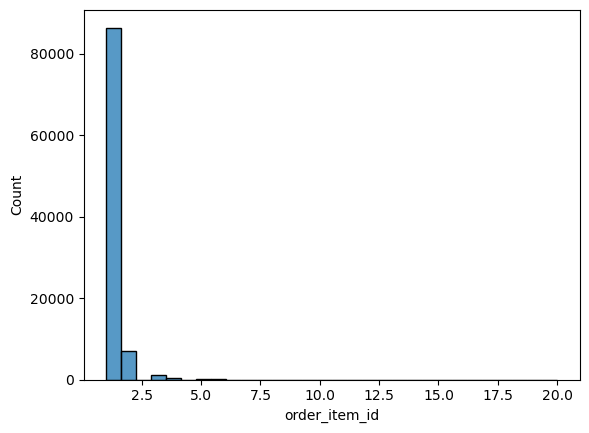

In [40]:
qtd_itens_pedidos = df.groupby('order_id')['order_item_id'].count()
sns.histplot(data = qtd_itens_pedidos,bins=30)

#neste histograma nós analisamos a quantidade de itens comprados em cada pedido. Como fica muito evidente pela concentração absoluta na primeira barra,
#a esmagadora maioria dos nossos clientes compra apenas um único item por vez. Pedidos com dois produtos são uma minoria, e com três ou mais são extremamente raros.
#O insight estratégico de negócio que tiramos daqui é que a empresa tem uma enorme oportunidade não explorada para aumentar o seu ticket médio. Como o cliente padrão entra,
#compra um produto e sai, poderíamos aumentar significativamente a receita aplicando estratégias de cross-sell (venda cruzada) — como sugerir produtos complementares na tela de checkout
#('compre junto') ou oferecer descontos no frete ao adicionar um segundo item ao carrinho.

<Axes: xlabel='tempo_atraso', ylabel='freight_value'>

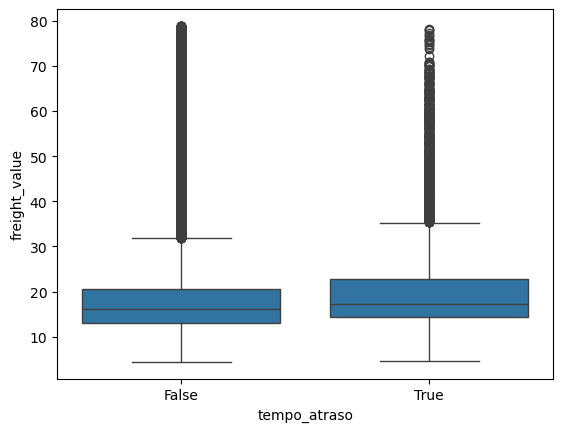

In [41]:
sns.boxplot(data = dfentregues,x = 'tempo_atraso', y = 'freight_value')

#neste boxplot nós cruzamos a ocorrência de atrasos na entrega (onde 'False' significa no prazo e 'True' significa atrasado) com o valor pago no frete.
#O que observamos visualmente é que as duas distribuições são muito semelhantes. A caixa dos pedidos que atrasaram apresenta uma mediana e um limite superior
#apenas ligeiramente mais altos do que a dos pedidos entregues no prazo. O principal insight de negócio aqui é desmistificar a intuição de que 'pagar um frete mais caro garante uma entrega sem atrasos'.
#Na verdade, como concluímos em gráficos anteriores, fretes mais caros geralmente indicam produtos mais volumosos ou destinos mais distantes.
#Portanto, faz todo o sentido logístico que essas entregas mais complexas e caras tenham uma leve tendência maior a sofrerem atrasos.

<Axes: xlabel='order_status'>

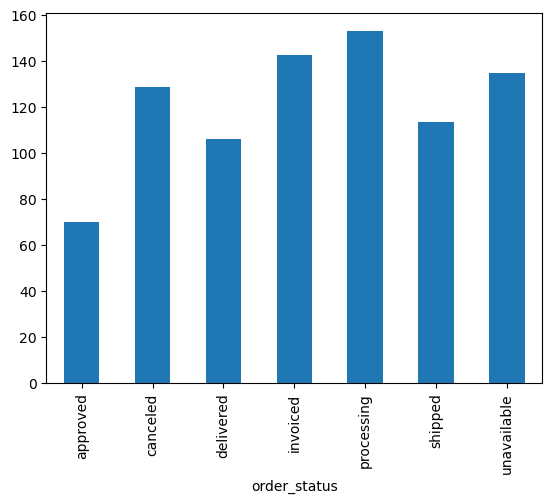

In [42]:
df.groupby('order_status')['price'].mean().plot(kind='bar')

#neste gráfico nós cruzamos o status do pedido com o preço médio dos produtos. O dado que mais chama atenção aqui é uma certa inversão de expectativa:
#os pedidos efetivamente concluídos e entregues ('delivered') possuem um ticket médio mais baixo, na faixa dos 100 a 110 reais. Em contrapartida,
#os pedidos que enfrentam algum tipo de gargalo — como os cancelados ('canceled'), indisponíveis ('unavailable') ou que estão travados em processamento ('processing')
#— apresentam os maiores preços médios, chegando à faixa dos 130 a 150 reais. O insight de negócio que tiramos disso é que itens mais caros sofrem mais fricção na jornada de compra.
#Eles tendem a demorar mais em análises de crédito (processamento), têm maior índice de desistência (cancelamento)
#e sofrem mais com rupturas de estoque, o que é um ponto de atenção crítico para a empresa, já que afeta diretamente os produtos de maior valor.

In [43]:
df.to_csv('olist_limpo_categorizado_projeto.csv', index=False)